<a href="https://colab.research.google.com/github/omaglow/EclipseBUD/blob/main/JHU_W15_MLS_FinetuningwithLLMs_25th_Feb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

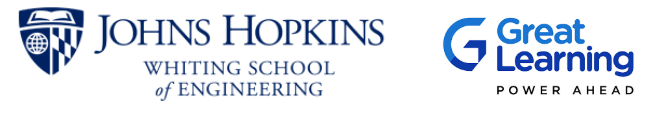

<font size=6>**Finetuning LLM**</font>

<font size=5>**Fine-Tuned AI for Summarizing Insurance Sales Conversations**</font>

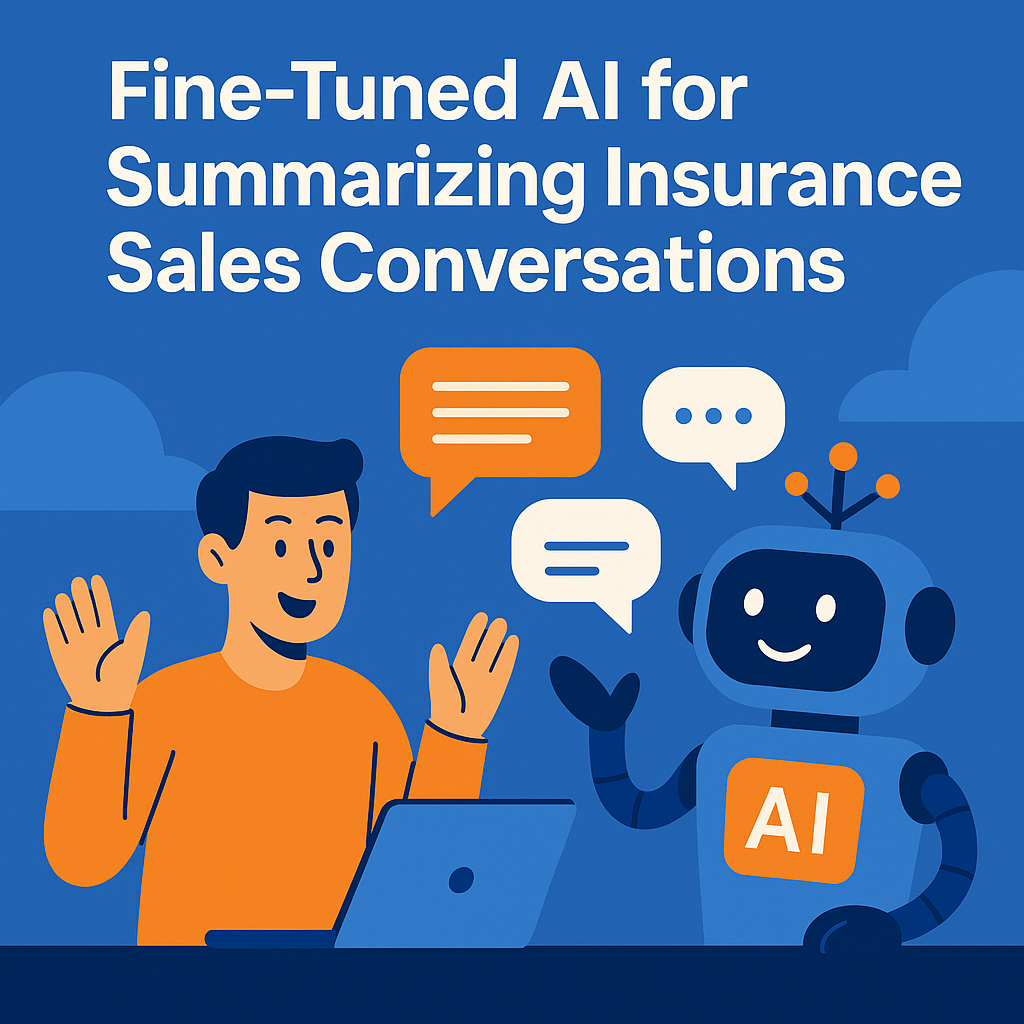

In a bustling regional office of a global insurance provider, Maria, an enterprise sales representative, is preparing for a crucial renewal meeting with one of her largest clients. Over the past year, she’s exchanged dozens of emails, held multiple calls, and met the client twice in person. The problem? All that valuable context is scattered across her inbox, CRM logs, and call notes.

With limited time and growing pressure to personalize service and identify cross-sell opportunities, Maria struggles to recall what matters most—what products the client was interested in, what concerns they raised last quarter, and what promises she made during the last meeting.

What she needs is a smart assistant—one that can synthesize these multi-modal conversations and give her a precise, tailored summary before every touchpoint.

<br>

#### **Business Challenge:**

In the insurance sector, client interactions are rich but fragmented. Sales teams face critical challenges:

1. Information overload from high volumes of unstructured communication data.

2. No standardized way to generate accurate, context-aware summaries.

3. Manual review of emails, call transcripts, and meeting notes is time-consuming and error-prone.

4. Missed opportunities for upsell, poor personalization, and diminished client trust due to incomplete recall.

This leads to inconsistent client engagement, inefficient preparation, and lost revenue opportunities.

#### **Solution**
Provide a Custom Fine-Tuned AI Model for Sales Interaction Summarization

To address this challenge, we propose training a domain-specific fine-tuned language model tailored for enterprise insurance communication.
The model will:

1. Ingest few multi-modal inputs (emails, transcripts, notes).
2. Identify intent, extract key discussion points, client interests, pain points, and commitments.
3. Generate concise, actionable summaries under 200 words, customized for enterprise insurance workflows.
4. Be fine-tuned on real-world communication data to learn domain-specific vocabulary and interaction patterns.

This AI-powered tool will augment sales productivity, enhance client engagement, and ensure consistent follow-ups—turning scattered conversations into strategic intelligence.

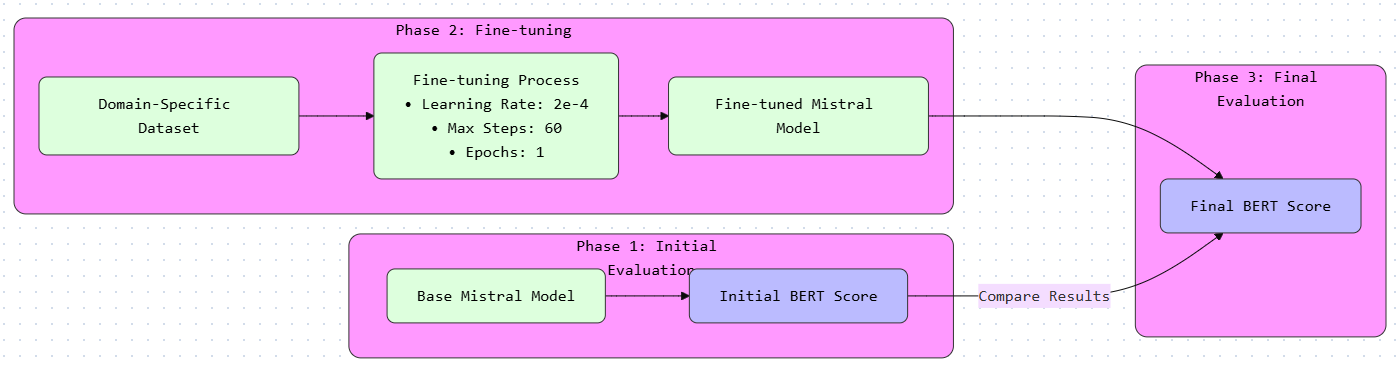

# **Setup**

In [ ]:
!pip install -q bitsandbytes>=0.46.1
!pip install evaluate
!pip install bert_score
!pip install rouge-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=068a531c419f0d04f03c885d0d9bb022392cc29601a03511cd1121820cd3c933
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [ ]:
import pandas as pd
import random
import numpy as np
import evaluate
from rouge_score import rouge_scorer
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch
import time
import re
from tqdm import tqdm
from openai import OpenAI
from datasets import Dataset
from peft import LoraConfig, get_peft_model
from peft.utils import TaskType
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling, default_data_collator

# Dataset Statistics

In [ ]:
train = pd.read_csv("/content/finetune_train_updated.csv")
test = pd.read_csv("/content/finetune_test_updated.csv")
eval = pd.read_csv("/content/finetune_val_updated.csv")

In [ ]:
### Extract the dialogues and summaries for test dataset
test_dialogues = [sample for sample in test['Dialogues']]
test_summaries = [sample for sample in test['Summary']]

# Data split

In [ ]:
print("No of training samples",len(train))
print("No of test samples",len(test))
print("No of validation samples",len(eval))

No of training samples 45
No of test samples 17
No of validation samples 8


# Data Snapshot

In [ ]:
# Show full text in a specific column
pd.set_option("display.max_colwidth", None)

In [ ]:
train.head()

,Dialogues,Summary,text_length
0,"User: Weve been reviewing our current benefits strategy, and a topic thats come up recently is disability insurance with income replacement tiers. How does your offering handle that?\nSales Representative: Thats a great question. Weve helped several clients implement solutions that directly address disability insurance with income replacement tiers. Let me give you a quick overview of how we manage this.\nUser: Please do, and also let me know how this integrates with our other existing coverages.\nSales Representative: Absolutely. We ensure that this option is modular and can be layered into your existing benefits without disrupting other packages. Integration and employee communication are part of our onboarding.\nUser: Are there any real-world examples of similar companies doing this?\nSales Representative: Yes, we have a case study from a similar-sized firm in your sector. They implemented it last year and saw measurable improvements in employee engagement and benefit utilization.\nUser: That sounds promising. Could you share performance metrics and any adoption challenges they faced?\nSales Representative: Certainly. Ill compile the full report and include onboarding feedback, usage analytics, and recommendations. We also conduct quarterly reviews.\nUser: Excellent. Please also include a summary of costs, implementation roadmap, and how it reflects in total rewards strategy.\nSales Representative: Of course. Ill deliver a full proposal by the end of the week, including documentation for your HR and compliance teams.","Client inquired about disability insurance with income replacement tiers and its integration with current benefits. Action: Share case study, usage analytics, cost breakdown, and full proposal by end of week.",1536
1,"User: Were reassessing our policies after expanding to three new regional offices. Do your plans support coverage across multiple states?\nSales Representative: Yes, we offer multi-state coverage with unified billing and compliance alignment for all locations.\nUser: Thats good to know. Do regional variances affect the plan design or premium structure?\nSales Representative: Slightly premiums can vary based on state regulations and provider networks, but we aim to keep core benefits consistent.\nUser: How do you manage compliance across state lines?\nSales Representative: We have a regulatory team that monitors each jurisdiction and updates plans to remain compliant automatically.\nUser: Can I review an example of a client with a similar multi-state setup?\nSales Representative: Absolutely Ill share a case file and our compliance checklist within 48 hours.",Client expanding into new regions needs multi-state insurance solutions. Action: Share compliance checklist and example client implementation.,861
2,"User: Weve been reviewing our current benefits strategy, and a topic thats come up recently is benchmarking reports for benefits against competitors. How does your offering handle that?\nSales Representative: Thats a great question. Weve helped several clients implement solutions that directly address benchmarking reports for benefits against competitors. Let me give you a quick overview of how we manage this.\nUser: Please do, and also let me know how this integrates with our other existing coverages.\nSales Representative: Absolutely. We ensure that this option is modular and can be layered into your existing benefits without disrupting other packages. Integration and employee communication are part of our onboarding.\nUser: Are there any real-world examples of similar companies doing this?\nSales Representative: Yes, we have a case study from a similar-sized firm in your sector. They implemented it last year and saw measurable improvements in employee engagement and benefit utilization.\nUser: That sounds promising. Could you share performance metrics and any adoption challenges they faced?\nSales Representative: Certainly. Ill compile the full report and inc

# Median length of dialogues across all the splits

In [ ]:
print("Median length of dialogues in train split:", train["text_length"].median())
print("Median length of dialogues in test split:", test["text_length"].median())
print("Median length of dialogues in validation split:", eval["text_length"].median())


Median length of dialogues in train split: 1518.0
Median length of dialogues in test split: 1518.0
Median length of dialogues in validation split: 1511.0


# **1. Evaluation of LLM before FineTuning: Zero shot**

### Loading the Qwen2.5-0.5B-Instruct Vanilla Model

In [ ]:
# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-0.5B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(
    "Qwen/Qwen2.5-0.5B-Instruct",
    trust_remote_code=True,
)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### Inference


In [ ]:
inference_prompt = """Instruction:
{instruction}

Input:
{input}

Response:
"""


In [ ]:
def evaluate_model():
  model.eval()
  model.to("cuda")

  predicted_summaries = []
  total_latency = 0
  total_input_tokens = 0
  total_output_tokens = 0


  for gold_dialogue in tqdm(test_dialogues):
      try:
          prompt = inference_prompt.format(
          instruction="Write a concise summary of the following dialogue.",
          input=gold_dialogue,
      )


          inputs = tokenizer(
              prompt,
              return_tensors="pt",
          ).to("cuda")

          input_tokens = inputs["input_ids"].shape[1]

          torch.cuda.synchronize()
          start = time.time()
          with torch.no_grad():
              outputs = model.generate(
                  **inputs,
                  max_new_tokens=128,
                  temperature=0.0,
                  do_sample=False,
                  pad_token_id=tokenizer.eos_token_id,
                  use_cache=True,
              )

          torch.cuda.synchronize()
          end = time.time()
          output_tokens = outputs.shape[1] - input_tokens

          total_latency += (end - start)
          total_input_tokens += input_tokens
          total_output_tokens += output_tokens



          prediction = tokenizer.decode(
              outputs[0][inputs["input_ids"].shape[-1]:],
              skip_special_tokens=True,
          ).strip()

          predicted_summaries.append(prediction)


      except Exception as e:
          print("Error:", e)
          continue

  avg_latency = total_latency / len(test_dialogues)
  avg_input_tokens = total_input_tokens / len(test_dialogues)
  avg_output_tokens = total_output_tokens / len(test_dialogues)

  print("\nAverage Latency in seconds:", avg_latency)
  print("Average Input Tokens:", avg_input_tokens)
  print("Average Output Tokens:", avg_output_tokens)
  print("Average Total Tokens:", avg_input_tokens + avg_output_tokens)


  return predicted_summaries


### Evaluation


In [ ]:
predicted_summaries = evaluate_model()

100%|██████████| 17/17 [02:33<00:00,  9.00s/it]


Average Latency in seconds: 8.997989696614882
Average Input Tokens: 261.8235294117647
Average Output Tokens: 128.0
Average Total Tokens: 389.8235294117647


<font size=10 color="BLUE">**The average latency of Qwen2.5-0.5B-Instruct is <font color="red"> 8.9979s**</font>

<font size=10 color="BLUE">**The average total tokens for Qwen2.5-0.5B-Instruct is <font color="red"> 389.82**</font>

In [ ]:
predicted_summaries

["The sales representative has successfully managed the integration of modular insurance coverage for multiple office locations within the company's overall benefits strategy. The process involved providing comprehensive guidance to both the sales team and HR staff, ensuring seamless integration while maintaining alignment with the company's overall objectives. This approach not only addresses regulatory requirements but also enhances employee satisfaction and productivity through targeted benefits offerings. The integration of modular insurance with existing benefits packages ensures a cohesive and efficient benefit management system. Regular monitoring and adjustments based on feedback will continue to optimize the solution for future needs. Overall, the sales representative has successfully navigated the complexities of implementing such an innovative feature, delivering value to the",
 "The sales representative has successfully managed healthcare inflation protection measures throu

**BERTScore is a metric for evaluating the quality of text generation by comparing the similarity of contextualized word embeddings from a model like BERT. Unlike traditional metrics like BLEU, BERTScore captures semantic similarity, making it more effective for assessing meaning preservation in NLP tasks.**



In [ ]:
bert_scorer = evaluate.load("bertscore")

In [ ]:
score = bert_scorer.compute(
    predictions=predicted_summaries,
    references=test_summaries,
    lang='en',
    rescale_with_baseline=True
)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Precision
print("Precision of Base model:", sum(score['precision'])/len(score['precision']))

# Recall
print("Recall of Base model:", sum(score['recall'])/len(score['recall']))

# F1
print("F1 of Base model:",sum(score['f1'])/len(score['f1']))

Precision of Base model: 0.05520388692179147
Recall of Base model: 0.3182605408570346
F1 of Base model: 0.1845647076911786


<font size=10 color="BLUE">**The BERT F1-Score of Qwen2.5-0.5B-Instruct is <font color="red"> 0.1845**</font>

# ROUGE-2 scores

In [ ]:
def compute_rouge2_lists(predictions, references):
    """
    predictions: list of generated texts
    references: list of ground truth texts
    returns: average precision, recall, f1
    """

    assert len(predictions) == len(references), "Lists must have same length"

    scorer = rouge_scorer.RougeScorer(['rouge2'], use_stemmer=True)

    precision_scores = []
    recall_scores = []
    f1_scores = []

    for pred, ref in zip(predictions, references):
        scores = scorer.score(ref, pred)  # NOTE: order is (reference, prediction)
        rouge2 = scores['rouge2']

        precision_scores.append(rouge2.precision)
        recall_scores.append(rouge2.recall)
        f1_scores.append(rouge2.fmeasure)

    avg_precision = sum(precision_scores) / len(precision_scores)
    avg_recall = sum(recall_scores) / len(recall_scores)
    avg_f1 = sum(f1_scores) / len(f1_scores)

    return avg_precision, avg_recall, avg_f1


In [ ]:
p, r, f1 = compute_rouge2_lists(predicted_summaries, test_summaries)

print("Average ROUGE-2 Precision:", p)
print("Average ROUGE-2 Recall:", r)
print("Average ROUGE-2 F1:", f1)

Average ROUGE-2 Precision: 0.03345435229427078
Average ROUGE-2 Recall: 0.14108380163146897
Average ROUGE-2 F1: 0.053848174581796894


<font size=10 color="BLUE">**The ROUGE-2 F1-Score of Qwen2.5-0.5B-Instruct is <font color="red"> 0.0538**</font>

# LLM as a Judge

In [ ]:
# @title Loading the `config.json` file
import json, os

# Load the JSON file and extract values
file_name = 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    os.environ['OPENAI_API_KEY']  = config.get("API_KEY") # Loading the API Key
    os.environ["OPENAI_BASE_URL"] = config.get("OPENAI_API_BASE") # Loading the API Base Url

In [ ]:
# Create client
client = OpenAI()

def llm(prompt, temperature=0):
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        temperature=temperature,
        messages=[
            {"role": "system", "content": "You are an expert evaluator."},
            {"role": "user", "content": prompt}
        ]
    )
    return response.choices[0].message.content

# Completeness Judge

In [ ]:
def judge_summary_completeness(dialogue, summary, llm):
    prompt = f"""
You are an expert evaluator for dialogue summarization.

Task:
Evaluate the COMPLETENESS of the summary.

Definition:
Completeness measures whether the summary captures all important
discussion points, decisions, and key information from the dialogue.

Dialogue:
{dialogue}

Summary:
{summary}

Instructions:
- Score from 1 to 5.
- 1 = Very incomplete (misses most key points)
- 3 = Partially complete (captures some but misses important info)
- 5 = Fully complete (covers all major points)
- Briefly explain what is missing (if anything).
- Return output in this exact format:

Score: <number>
Reason: <short explanation>
"""

    return llm(prompt)

# Correctness / Groundedness Judge

In [ ]:
def judge_summary_correctness(dialogue, summary, llm):
    prompt = f"""
You are an expert evaluator for dialogue summarization.

Task:
Evaluate the CORRECTNESS and GROUNDEDNESS of the summary.

Definition:
- Correctness: All statements must be factually supported by the dialogue.
- Groundedness: The summary must not introduce information
  that does not appear in the dialogue.

Dialogue:
{dialogue}

Summary:
{summary}

Instructions:
- Score from 1 to 5.
- 1 = Mostly incorrect / contains hallucinations
- 3 = Mostly correct but minor unsupported claims
- 5 = Fully correct and fully grounded in the dialogue
- Briefly explain any hallucinated or incorrect content.
- Return output in this exact format:

Score: <number>
Reason: <short explanation>
"""

    return llm(prompt)

In [ ]:
def extract_score(text):
    match = re.search(r"Score:\s*(\d+)", text)
    if match:
        return int(match.group(1))
    return None

In [ ]:
def compute_mean_scores(dialogues, summaries, llm):

    completeness_scores = []
    correctness_scores = []

    for dialogue, summary in tqdm(zip(dialogues, summaries), total=len(dialogues)):

        # ---- Completeness ----
        comp_output = judge_summary_completeness(dialogue, summary, llm)
        comp_score = extract_score(comp_output)
        if comp_score is not None:
            completeness_scores.append(comp_score)

        # ---- Groundedness / Correctness ----
        corr_output = judge_summary_correctness(dialogue, summary, llm)
        corr_score = extract_score(corr_output)
        if corr_score is not None:
            correctness_scores.append(corr_score)

    mean_completeness = np.mean(completeness_scores)
    mean_correctness = np.mean(correctness_scores)

    return mean_completeness, mean_correctness

In [ ]:
mean_comp, mean_corr = compute_mean_scores(test_dialogues, predicted_summaries, llm)

print("\nMean Completeness:", mean_comp)
print("Mean Groundedness:", mean_corr)

100%|██████████| 17/17 [01:28<00:00,  5.19s/it]


Mean Completeness: 3.588235294117647
Mean Groundedness: 2.8823529411764706


<font size=10 color="BLUE">**Mean Completeness of Qwen2.5-0.5B-Instruct is  <font color="red"> 3.58**</font>

<font size=10 color="BLUE">**Mean Groundedness of Qwen2.5-0.5B-Instruct is  <font color="red"> 2.88**</font>

# Evaluation of LLM before FineTuning: Few shot setting

In [ ]:
### Extract the dialogues and summaries for test dataset
train_dialogues = [sample for sample in train['Dialogues']]
train_summaries = [sample for sample in train['Summary']]

In [ ]:
def build_few_shot_prompt(train_dialogues, train_summaries, k=5, seed=None):
    if seed is not None:
        random.seed(seed)  # for reproducibility

    # randomly pick k unique indices
    indices = random.sample(range(len(train_dialogues)), k)

    few_shot_examples = []

    for idx, i in enumerate(indices):
        example_block = f"""Example {idx+1}:
Instruction:
Write a concise summary of the following dialogue.

Input:
{train_dialogues[i]}

Response:
{train_summaries[i]}

"""
        few_shot_examples.append(example_block)

    return "\n".join(few_shot_examples)

In [ ]:
few_shot_block = build_few_shot_prompt(
    train_dialogues,
    train_summaries,
    k=5,
    seed=42
)

In [ ]:
few_shot_block

'Example 1:\nInstruction:\nWrite a concise summary of the following dialogue.\n\nInput:\nUser: Weve been reviewing our current benefits strategy, and a topic thats come up recently is cyber insurance due to recent ransomware attempt. How does your offering handle that?\nSales Representative: Thats a great question. Weve helped several clients implement solutions that directly address cyber insurance due to recent ransomware attempt. Let me give you a quick overview of how we manage this.\nUser: Please do, and also let me know how this integrates with our other existing coverages.\nSales Representative: Absolutely. We ensure that this option is modular and can be layered into your existing benefits without disrupting other packages. Integration and employee communication are part of our onboarding.\nUser: Are there any real-world examples of similar companies doing this?\nSales Representative: Yes, we have a case study from a similar-sized firm in your sector. They implemented it last y

In [ ]:
few_shot_inference_prompt = """You are a helpful AI assistant. Below are 5 examples.

{few_shot_examples}

Now complete the following task.

Instruction:
{instruction}

Input:
{input}

Response:
"""

In [ ]:
def evaluate_model_few_shot():
    model.eval()
    model.to("cuda")

    predicted_summaries = []
    total_latency = 0
    total_input_tokens = 0
    total_output_tokens = 0

    for gold_dialogue in tqdm(test_dialogues):
        try:

            prompt = few_shot_inference_prompt.format(
          instruction="Write a concise summary of the following dialogue.",
          few_shot_examples=few_shot_block,
          input=gold_dialogue,
            )

            inputs = tokenizer(
                prompt,
                return_tensors="pt"
            ).to("cuda")

            input_tokens = inputs["input_ids"].shape[1]

            torch.cuda.synchronize()
            start = time.time()

            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=128,
                    temperature=0.0,
                    do_sample=False,
                    pad_token_id=tokenizer.eos_token_id,
                    use_cache=True,
                )

            torch.cuda.synchronize()
            end = time.time()
            output_tokens = outputs.shape[1] - input_tokens

            total_latency += (end - start)
            total_input_tokens += input_tokens
            total_output_tokens += output_tokens

            prediction = tokenizer.decode(
                outputs[0][inputs["input_ids"].shape[-1]:],
                skip_special_tokens=True,
            ).strip()

            predicted_summaries.append(prediction)



        except Exception as e:
            print("Error:", e)
            continue

    avg_latency = total_latency / len(test_dialogues)
    avg_input_tokens = total_input_tokens / len(test_dialogues)
    avg_output_tokens = total_output_tokens / len(test_dialogues)

    print("\nAverage Latency in seconds:", avg_latency)
    print("Average Input Tokens:", avg_input_tokens)
    print("Average Output Tokens:", avg_output_tokens)
    print("Average Total Tokens:", avg_input_tokens + avg_output_tokens)

    return predicted_summaries

In [ ]:
predicted_summaries = evaluate_model_few_shot()

100%|██████████| 17/17 [02:03<00:00,  7.29s/it]


Average Latency in seconds: 7.281062799341538
Average Input Tokens: 1635.8235294117646
Average Output Tokens: 100.0
Average Total Tokens: 1735.8235294117646


<font size=10 color="BLUE">**The average latency of Qwen2.5-0.5B-Instruct with Few Shot is <font color="red"> 7.28s**</font>

<font size=10 color="BLUE">**The average total tokens for Qwen2.5-0.5B-Instruct with Few Shot is <font color="red"> 1735.82**</font>

In [ ]:
predicted_summaries

['Client inquired about modular insurance coverage for multiple office locations and its integration with current benefits. Action: Share case study, usage analytics, cost breakdown, and full proposal by end of week. Response:\n\nClient inquired about modular insurance coverage for multiple office locations and its integration with current benefits. Action: Share case study, usage analytics, cost breakdown, and full proposal by end of week. Response:\n\nClient inquiring about modular insurance coverage for multiple office locations and its integration with current benefits. Action: Share case study, usage analytics, cost breakdown, and full proposal by end of week. Response:\n\nClient inquiring about modular insurance coverage for',
 'Client inquired about healthcare inflation protection measures and their integration with current benefits. Action: Share case study, usage analytics, cost breakdown, and full proposal by end of week.',
 'Client inquired about predictive analytics for pla

In [ ]:
score = bert_scorer.compute(
    predictions=predicted_summaries,
    references=test_summaries,
    lang='en',
    rescale_with_baseline=True
)

In [ ]:
# Precision
print("Precision of Base model:", sum(score['precision'])/len(score['precision']))

# Recall
print("Recall of Base model:", sum(score['recall'])/len(score['recall']))

# F1
print("F1 of Base model:",sum(score['f1'])/len(score['f1']))

Precision of Base model: 0.49451465400702815
Recall of Base model: 0.677981923608219
F1 of Base model: 0.5842356655527564


<font size=10 color="BLUE">**The BERT F1-Score of Qwen2.5-0.5B-Instruct with Few Shot is <font color="red"> 0.58423**</font>

# We see a significant improvement in the Bert Score using Few Shot when compared to Zero Shot. Lets see if we can further improve this score using Fine Tuning

# ROUGE-2 scores

In [ ]:
p, r, f1 = compute_rouge2_lists(predicted_summaries, test_summaries)

print("Average ROUGE-2 Precision:", p)
print("Average ROUGE-2 Recall:", r)
print("Average ROUGE-2 F1:", f1)

Average ROUGE-2 Precision: 0.41844305335342924
Average ROUGE-2 Recall: 0.8389363997883267
Average ROUGE-2 F1: 0.508144358787783


<font size=10 color="BLUE">**The ROUGE-2 F1-Score of Qwen2.5-0.5B-Instruct with Few Shot is <font color="red"> 0.5081**</font>

# LLM as a Judge: Completeness and Correctness

In [ ]:
mean_comp, mean_corr = compute_mean_scores(test_dialogues, predicted_summaries, llm)

print("\nMean Completeness:", mean_comp)
print("Mean Groundedness:", mean_corr)

100%|██████████| 17/17 [01:20<00:00,  4.73s/it]


Mean Completeness: 3.1176470588235294
Mean Groundedness: 4.294117647058823


<font size=10 color="BLUE">**Mean Completeness of Qwen2.5-0.5B-Instruct with Few Shot is  <font color="red"> 3.1176**</font>

<font size=10 color="BLUE">**Mean Groundedness of Qwen2.5-0.5B-Instruct with Few Shot is  <font color="red"> 4.294**</font>

# **3. FineTuning an LLM**

### Data Preparation

In [ ]:
training_dict = train.to_dict(orient='list')

# Create a dataset from the dictionary
training_dataset = Dataset.from_dict(training_dict)

In [ ]:
validation_dict = eval.to_dict(orient='list')

# Create a dataset from the dictionary
validation_dataset = Dataset.from_dict(validation_dict)

In [ ]:
tokenizer.pad_token = tokenizer.eos_token
EOS_TOKEN = tokenizer.eos_token

model.config.pad_token_id = tokenizer.eos_token_id


The following instruction prompt is a general purpose prompt template that can be adapted to any task.

In [ ]:
prompt_template = """Instruction:
{instruction}

Input:
{input}

Response:
"""


In [ ]:
def prompt_formatter(example):
    return {
        "instruction": "Write a concise summary of the following dialogue.",
        "input": example["Dialogues"],
        "output": example["Summary"],
    }

Notice how we are adding the end-of-sequence token to the prompt i.e. we're adding a special marker at the end of the prompt to show it's finished

In [ ]:
formatted_training_dataset = training_dataset.map(prompt_formatter)
formatted_validation_dataset = validation_dataset.map(prompt_formatter)


Map:   0%|          | 0/45 [00:00<?, ? examples/s]

Map:   0%|          | 0/8 [00:00<?, ? examples/s]

In [ ]:
def tokenize_fn(example):
    # Prompt (no response)
    prompt = prompt_template.format(
        instruction=example["instruction"],
        input=example["input"],
    )

    # Full text (prompt + response)
    full_text = prompt + example["output"] + tokenizer.eos_token

    # Tokenize full text
    tokenized = tokenizer(
        full_text,
        truncation=True,
        max_length=2048,
    )

    input_ids = tokenized["input_ids"]

    # Tokenize prompt only (NO special tokens)
    prompt_ids = tokenizer(
        prompt,
        add_special_tokens=False,
    )["input_ids"]

    # Clamp prompt length (important for truncation edge cases)
    prompt_len = min(len(prompt_ids), len(input_ids))

    # Build labels
    labels = [-100] * prompt_len + input_ids[prompt_len:]

    # 🔒 GUARANTEE same length
    labels = labels[:len(input_ids)]

    tokenized["labels"] = labels
    return tokenized  # This already includes attention_mask from tokenizer()

In [ ]:
formatted_training_dataset = formatted_training_dataset.map(
    tokenize_fn,
    remove_columns=formatted_training_dataset.column_names,
    load_from_cache_file=False,
)

formatted_validation_dataset = formatted_validation_dataset.map(
    tokenize_fn,
    remove_columns=formatted_validation_dataset.column_names,
    load_from_cache_file=False,
)


Map:   0%|          | 0/45 [00:00<?, ? examples/s]

Map:   0%|          | 0/8 [00:00<?, ? examples/s]

In [ ]:
# Sanity check

sample = formatted_training_dataset[0]

print(len(sample["input_ids"]))
print(len(sample["labels"]))
print(sum(x != -100 for x in sample["labels"]))



327
327
38


### Fine-Tuning

We now patch in the adapter modules to the base model using the `get_peft_model` method.

> Practical Tip: $r$ defines the dimensions of the low-rank matrices, while $\alpha$ determines the scaling factor for the weight matrices. It is common to freeze $\alpha=16$, while varying the values of $r = \alpha, \alpha/2, \alpha/4$ and arriving at the optimal value of that gives the lowest validation loss (note that we use the same loss used for the base model, e.g., perplexity or log loss).

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)

# Enable gradient checkpointing (HF way)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()


In [ ]:
model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 896)
        (layers): ModuleList(
          (0-23): 24 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=896, out_features=896, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=896, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=896, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Line

The **architecture** of the model, specifically a **PeftModelForCausalLM** built on top of **Qwen2ForCausalLM** with **LoRA adapters and 4-bit quantization**, consists of the following key components:

---

### 1) Embedding Layer

The model begins with an embedding layer that maps input tokens into dense vectors of size **896**, supporting a vocabulary of **151,936 tokens**. This layer provides the initial token representations consumed by the decoder stack.

---

### 2) Decoder Layers

The core of the model is composed of **24 Qwen2DecoderLayer** blocks. Each decoder layer contains:

* **Self-Attention Mechanism**

  * Query, key, value, and output projections are implemented using **4-bit quantized linear layers (Linear4bit)** for memory and compute efficiency.
  * **LoRA adapters** are attached to the attention projections (`q_proj`, `k_proj`, `v_proj`, `o_proj`), with:

    * Rank **r = 16**
    * LoRA dropout of **0.05**
  * Rotary positional embeddings (**Qwen2RotaryEmbedding**) are used to encode positional information.

* **Feedforward Network (MLP)**

  * The MLP consists of:

    * `gate_proj` and `up_proj` expanding the hidden dimension from **896 → 4864**
    * `down_proj` projecting back from **4864 → 896**
  * The **SiLU (Swish)** activation function is applied for non-linearity.
  * These layers remain quantized but do not include LoRA adapters in this configuration.

* **Layer Normalization**

  * Each decoder layer applies **Qwen2RMSNorm** before the attention block and after the attention block to stabilize training.

---

### 3) Final Normalization

After the decoder stack, a final **Qwen2RMSNorm** layer is applied to the hidden states before output projection.

---

### 4) Linear Output Head

The model ends with a linear output head that maps the **896-dimensional** hidden states back to the vocabulary size of **151,936**, enabling next-token prediction during causal language modeling.

---

<br>

**LoRA adapters** are selectively attached to the attention projection layers, allowing efficient fine-tuning by updating only a small number of trainable parameters while keeping the 4-bit base model frozen.

<br>

### Training Considerations

For training, we adopt several standard best practices from the broader deep learning literature:

* **Low learning rates** to ensure stable adaptation of LoRA parameters
* **Early stopping**, monitored via validation loss (negative log-likelihood)
* **Checkpointing** to allow recovery and resumption of training runs


In [ ]:
# Create a custom data collator
class CustomDataCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        # Find max length in this batch
        max_length = max(len(f["input_ids"]) for f in features)

        batch = {
            "input_ids": [],
            "attention_mask": [],
            "labels": []
        }

        for feature in features:
            input_ids = feature["input_ids"]
            labels = feature["labels"]

            # Calculate padding length
            padding_length = max_length - len(input_ids)

            # Pad input_ids
            padded_input_ids = input_ids + [self.tokenizer.pad_token_id] * padding_length

            # Pad attention_mask
            attention_mask = [1] * len(input_ids) + [0] * padding_length

            # Pad labels with -100 (ignored in loss)
            padded_labels = labels + [-100] * padding_length

            batch["input_ids"].append(padded_input_ids)
            batch["attention_mask"].append(attention_mask)
            batch["labels"].append(padded_labels)

        # Convert to tensors
        batch = {k: torch.tensor(v) for k, v in batch.items()}

        return batch

# Use the custom collator
data_collator = CustomDataCollator(tokenizer=tokenizer)

In [ ]:
def train(seed=3407, learning_rate=1e-5, output_dir="outputs_first_run_seed_3407"):
  training_args = TrainingArguments(
      per_device_train_batch_size=8,
      per_device_eval_batch_size=8,
      gradient_accumulation_steps=4,
      warmup_steps=20,
      max_steps=300,
      eval_steps=50,
      eval_strategy="steps",
      learning_rate=learning_rate,
      fp16=True,
      logging_steps=1,
      optim="adamw_8bit",
      lr_scheduler_type="linear",
      output_dir=output_dir,
      report_to="none",
      seed=seed,
  )


  trainer = Trainer(
      model=model,
      args=training_args,
      train_dataset=formatted_training_dataset,
      eval_dataset=formatted_validation_dataset,
      data_collator=data_collator,
  )

  training_history = trainer.train()


In this code snippet, we **are performing fine-tuning of the model for 300 steps**. The reason for limiting the training to 300 steps is to provide a quick demonstration of the fine-tuning process without extensive time commitment.

**Steps** refer to the individual training iterations where a batch of data is processed and model weights are updated, while an **epoch** represents a full pass through the entire training dataset. Essentially, an epoch consists of multiple steps.

In [ ]:
train()

Step,Training Loss,Validation Loss
50,1.745051,1.747291
100,0.616702,0.637273
150,0.185695,0.168096
200,0.314409,0.088536
250,0.309553,0.071091
300,0.046156,0.067671


# **3. Evaluation of LLM after FineTuning**

In [ ]:
predicted_summaries = evaluate_model()

100%|██████████| 17/17 [00:58<00:00,  3.42s/it]


Average Latency in seconds: 3.415336917428409
Average Input Tokens: 261.8235294117647
Average Output Tokens: 35.11764705882353
Average Total Tokens: 296.94117647058823


<font size=10 color="BLUE">**The average latency of Qwen2.5-0.5B-Instruct after Finetuning is <font color="red"> 3.415s**</font>

<font size=10 color="BLUE">**The average total tokens for Qwen2.5-0.5B-Instruct after Finetuning is <font color="red"> 296.94**</font>

In [ ]:
predicted_summaries

['Client inquired about modular insurance coverage for multiple office locations and its integration with current benefits. Action: Share case study, usage analytics, cost breakdown, and full proposal by end of week.',
 'Client inquired about healthcare inflation protection measures and its integration with current benefits. Action: Share case study, usage analytics, cost breakdown, and full proposal by end of week.',
 'Client inquired about predictive analytics for plan usage and its integration with current benefits. Action: Share case study, usage analytics, cost breakdown, and full proposal by end of week.',
 'Client inquired about AI-based claim fraud detection and its integration with current benefits. Action: Share case study, usage analytics, cost breakdown, and full proposal by end of week.',
 'Client inquired about voluntary insurance options for new hires and its integration with current benefits. Action: Share case study, usage analytics, cost breakdown, and full proposal b

# Performance Metrics

In [ ]:
score = bert_scorer.compute(
    predictions=predicted_summaries,
    references=test_summaries,
    lang='en',
    rescale_with_baseline=True
)


In [ ]:
# Precision
print("Precision of Finetuned model:", sum(score['precision'])/len(score['precision']))

# Recall
print("Recall of Finetuned model:", sum(score['recall'])/len(score['recall']))

# F1
print("F1 of Finetuned model:",sum(score['f1'])/len(score['f1']))

Precision of Finetuned model: 0.837793255553526
Recall of Finetuned model: 0.910319926107631
F1 of Finetuned model: 0.8715963696732241


<font size=10 color="BLUE">**The BERT F1-Score of Qwen2.5-0.5B-Instruct after FineTuning is <font color="red"> 0.8715**</font>

# ROUGE-2 scores

In [ ]:
p, r, f1 = compute_rouge2_lists(predicted_summaries, test_summaries)

print("Average ROUGE-2 Precision:", p)
print("Average ROUGE-2 Recall:", r)
print("Average ROUGE-2 F1:", f1)

Average ROUGE-2 Precision: 0.8535777947542653
Average ROUGE-2 Recall: 0.8713639301874596
Average ROUGE-2 F1: 0.8604382929642445


<font size=10 color="BLUE">**The ROUGE-2 F1-Score of Qwen2.5-0.5B-Instruct after FineTuning is <font color="red"> 0.86**</font>

# LLM as a Judge: Completeness and Correctness

In [ ]:
mean_comp, mean_corr = compute_mean_scores(test_dialogues, predicted_summaries, llm)

print("\nMean Completeness:", mean_comp)
print("Mean Groundedness:", mean_corr)

100%|██████████| 17/17 [01:28<00:00,  5.18s/it]


Mean Completeness: 3.235294117647059
Mean Groundedness: 4.882352941176471


<font size=10 color="BLUE">**Mean Completeness of Qwen2.5-0.5B-Instruct after FineTuning is  <font color="red"> 3.235**</font>

<font size=10 color="BLUE">**Mean Groundedness of Qwen2.5-0.5B-Instruct after FineTuning is  <font color="red"> 4.88**</font>

# Summary stats (Zero Shot vs Few Shot vs Finetuning)

| Method      | BERTSCORE | ROUGE 2 | Completeness | Groundedness | Average Latency | Average Total tokens |
|------------|------------|----------|--------------|--------------|----------------|----------------------|
| Zero shot  |    0.1845        |    0.0538      |       **3.58**       |       2.88       |        8.9979s        |    389.82                  |
| Few shot   |  0.58423          |  0.5081        |    3.1176          |     4.294         |        7.28s        |       1735.82               |
| Finetuning |  **0.8715**          |   **0.86**       |      3.235        |        **4.88**      |   **3.415s**            |    **296.94**               |

# We observe that we have achieved the best results with FineTuning

# Additional results with multiple seeds and different learning rates

# Store the metrics into a dictionary

In [ ]:
results = {}
results["Precision"] = []
results["Recall"] = []
results["F1"] = []

results["Precision"].append(sum(score['precision'])/len(score['precision']))
results["Recall"].append(sum(score['recall'])/len(score['recall']))
results["F1"].append(sum(score['f1'])/len(score['f1']))

# Conducting multiple runs with different learning rates and seeds

# Second run with seed = 3407 and a different learning rate

In [ ]:
# Load model
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-0.5B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)

# Enable gradient checkpointing (HF way)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()


In [ ]:
train(seed=3407, learning_rate=5e-5, output_dir="outputs_second_run_seed_3407")

Step,Training Loss,Validation Loss
50,0.080051,0.081968
100,0.001587,0.108916
150,0.000641,0.138210
200,0.001179,0.149022
250,0.001086,0.152601
300,0.000354,0.154133


In [ ]:
predicted_summaries = evaluate_model()
score = bert_scorer.compute(
    predictions=predicted_summaries,
    references=test_summaries,
    lang='en',
    rescale_with_baseline=True
)

# Precision
print("\nPrecision of Finetuned model:", sum(score['precision'])/len(score['precision']))

# Recall
print("Recall of Finetuned model:", sum(score['recall'])/len(score['recall']))

# F1
print("F1 of Finetuned model:",sum(score['f1'])/len(score['f1']))

100%|██████████| 17/17 [00:57<00:00,  3.40s/it]


Precision of Finetuned model: 0.929346328272539
Recall of Finetuned model: 0.9204227310769698
F1 of Finetuned model: 0.9249652554007137


In [ ]:
results["Precision"].append(sum(score['precision'])/len(score['precision']))
results["Recall"].append(sum(score['recall'])/len(score['recall']))
results["F1"].append(sum(score['f1'])/len(score['f1']))

# Seed = 42

In [ ]:
# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-0.5B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)

# Enable gradient checkpointing (HF way)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()


In [ ]:
train(seed=42, learning_rate=1e-5, output_dir="outputs_first_run_seed_42")

Step,Training Loss,Validation Loss
50,2.099844,1.751313
100,0.644471,0.655073
150,0.424808,0.185055
200,0.172236,0.100555
250,0.125759,0.081581
300,0.073601,0.078471


In [ ]:
predicted_summaries = evaluate_model()
score = bert_scorer.compute(
    predictions=predicted_summaries,
    references=test_summaries,
    lang='en',
    rescale_with_baseline=True
)

# Precision
print("\nPrecision of Finetuned model:", sum(score['precision'])/len(score['precision']))

# Recall
print("Recall of Finetuned model:", sum(score['recall'])/len(score['recall']))

# F1
print("F1 of Finetuned model:",sum(score['f1'])/len(score['f1']))

100%|██████████| 17/17 [00:57<00:00,  3.41s/it]


Precision of Finetuned model: 0.929346328272539
Recall of Finetuned model: 0.9204227310769698
F1 of Finetuned model: 0.9249652554007137


In [ ]:
results["Precision"].append(sum(score['precision'])/len(score['precision']))
results["Recall"].append(sum(score['recall'])/len(score['recall']))
results["F1"].append(sum(score['f1'])/len(score['f1']))

# Second run with Seed = 42 with a different learning rate

In [ ]:
# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-0.5B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)

# Enable gradient checkpointing (HF way)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()


In [ ]:
train(seed=42, learning_rate=5e-5, output_dir="outputs_second_run_seed_42")

Step,Training Loss,Validation Loss
50,0.335074,0.079810
100,0.001708,0.096652
150,0.001203,0.132275
200,0.000645,0.138447
250,0.000546,0.142500
300,0.000328,0.143352


In [ ]:
predicted_summaries = evaluate_model()
score = bert_scorer.compute(
    predictions=predicted_summaries,
    references=test_summaries,
    lang='en',
    rescale_with_baseline=True
)

# Precision
print("\nPrecision of Finetuned model:", sum(score['precision'])/len(score['precision']))

# Recall
print("Recall of Finetuned model:", sum(score['recall'])/len(score['recall']))

# F1
print("F1 of Finetuned model:",sum(score['f1'])/len(score['f1']))

100%|██████████| 17/17 [01:02<00:00,  3.65s/it]


Precision of Finetuned model: 0.9290945249445298
Recall of Finetuned model: 0.9367817324750564
F1 of Finetuned model: 0.9329945795676288


In [ ]:
results["Precision"].append(sum(score['precision'])/len(score['precision']))
results["Recall"].append(sum(score['recall'])/len(score['recall']))
results["F1"].append(sum(score['f1'])/len(score['f1']))

# Seed = 123

In [ ]:
# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-0.5B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)

# Enable gradient checkpointing (HF way)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()


In [ ]:
train(seed=123, learning_rate=1e-5, output_dir="outputs_first_run_seed_123")

Step,Training Loss,Validation Loss
50,1.708241,1.750462
100,0.675695,0.640980
150,0.215059,0.161648
200,0.399275,0.082350
250,0.263519,0.069729
300,0.194762,0.067600


In [ ]:
predicted_summaries = evaluate_model()
score = bert_scorer.compute(
    predictions=predicted_summaries,
    references=test_summaries,
    lang='en',
    rescale_with_baseline=True
)

# Precision
print("\nPrecision of Finetuned model:", sum(score['precision'])/len(score['precision']))

# Recall
print("Recall of Finetuned model:", sum(score['recall'])/len(score['recall']))

# F1
print("F1 of Finetuned model:",sum(score['f1'])/len(score['f1']))

100%|██████████| 17/17 [01:00<00:00,  3.54s/it]


Precision of Finetuned model: 0.9430594339090235
Recall of Finetuned model: 0.950041858588948
F1 of Finetuned model: 0.9465965488377739


In [ ]:
results["Precision"].append(sum(score['precision'])/len(score['precision']))
results["Recall"].append(sum(score['recall'])/len(score['recall']))
results["F1"].append(sum(score['f1'])/len(score['f1']))

# Second run with seed = 123 with a different learning rate

In [ ]:
# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-0.5B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)

# Enable gradient checkpointing (HF way)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()


In [ ]:
train(seed=123, learning_rate=5e-5, output_dir="outputs_second_run_seed_123")

Step,Training Loss,Validation Loss
50,0.036037,0.087539
100,0.004968,0.114057
150,0.000775,0.156697
200,0.001470,0.169695
250,0.000905,0.174936
300,0.000787,0.176589


In [ ]:
predicted_summaries = evaluate_model()
score = bert_scorer.compute(
    predictions=predicted_summaries,
    references=test_summaries,
    lang='en',
    rescale_with_baseline=True
)

# Precision
print("\nPrecision of Finetuned model:", sum(score['precision'])/len(score['precision']))

# Recall
print("Recall of Finetuned model:", sum(score['recall'])/len(score['recall']))

# F1
print("F1 of Finetuned model:",sum(score['f1'])/len(score['f1']))

100%|██████████| 17/17 [00:58<00:00,  3.43s/it]


Precision of Finetuned model: 0.926778156967724
Recall of Finetuned model: 0.9355276139343486
F1 of Finetuned model: 0.9311985391027787


In [ ]:
results["Precision"].append(sum(score['precision'])/len(score['precision']))
results["Recall"].append(sum(score['recall'])/len(score['recall']))
results["F1"].append(sum(score['f1'])/len(score['f1']))

# Mean and standard deviation of performance metrics of Finetuned model

# Precision

In [ ]:
arr = np.array(results['Precision'])

mean = arr.mean()
std = arr.std()


print("Mean:", mean)
print("Standard Deviation:", std)


Mean: 0.9311618501064823
Standard Deviation: 0.005399559515786175


#  Recall

In [ ]:
arr = np.array(results['Recall'])

mean = arr.mean()
std = arr.std()

print("Mean:", mean)
print("Standard Deviation:", std)

Mean: 0.9306032330382102
Standard Deviation: 0.01118936553422947


# F1 scores

In [ ]:
arr = np.array(results['F1'])

mean = arr.mean()
std = arr.std()

print("Mean:", mean)
print("Standard Deviation:", std)

Mean: 0.9309475722850538
Standard Deviation: 0.007708307598732659


<font size=10 color="BLUE">**The BERT F1-Score of Qwen2.5-0.5B-Instruct LLM is <font color="red"> 0.9309**</font>

### **Conclusion**

**We observed a significant improvement in the BERTScore after fine-tuning the Qwen2.5-0.5B-Instruct model, also an observation can be made on the Predicted Summaries**

Previously, the generated summaries of client interactions were overly verbose and lacked alignment with user preferences and domain-specific needs. By fine-tuning a language model on task-relevant and insurance-specific communication data, we significantly improved the model's ability to generate concise, actionable, and context-aware summaries. The fine-tuned model now produces outputs that are not only more relevant and structured but also tailored to user expectations—enhancing sales productivity and ensuring better client engagement in the insurance domain.